# Calibration

Four experiments, each producing one OM × GT Spearman-rho heatmap per
dataset (`vonto.calibration.run_calibration`, backed by
`vonto/calibration/calibration.py`'s own generation/observation/grading
cache — but this notebook wipes that cache at the top of every run, so what
it actually buys here is reuse *within* one run, e.g. experiment 2 not
redoing experiment 1's shared block, not reuse *across* reruns; see the setup
cell for why):

1. **Baseline calibration** — the 3×3 matched sentiment pairs
   (`ConfidenceOM`↔`CorrectnessGT`, `CommitmentOM`↔`ProbabilityGT`,
   `NuanceOM`↔`EntropyGT`) over the two general datasets (`SynonymsDataset`,
   `TriviaQA`).
2. **Full calibration** — the same two datasets, adding `ChallengeOM`/
   `ChallengeGT` as the third row/column for a 4×4 sweep. Shares experiment
   1's cache directory, so the three baseline rows/columns are loaded, not
   recomputed — only `challenge`'s row/column is actually generated fresh.
3. **List elicitation** — `VarietyOM` × `ListVarianceGT` only, over
   `ListElicitationDataset` — `variety` is exclusive to this dataset.
4. **Twenty questions** — `ImpurityOM` × `ImpurityGT` only, over
   `TwentyQuestionsDataset` — `impurity` is exclusive to this dataset (not
   shared with list elicitation): it grades how evenly the model's own
   newly proposed question splits the remaining candidates, self-reported
   vs. actually computed.

Every dataset the experiments below need is generated fresh in its own
**Datasets** section right after the setup cells — one **generation** cell
per dataset that always calls `generate()` and overwrites
`$PROJECT_ROOT/data/prepared/<name>.json` (no skip-if-already-cached check;
see the Datasets section intro for why), followed by a **verification** cell
that independently reads the saved file back via `load_if_cached()`. Every
generation/verification cell (any dataset) is self-contained — its own
imports and setup — so it runs on its own, in any order, without first
running any other cell. The Experiment cells that follow are not
independent in that sense: they build on the dataset variables the
verification cells produce, and on the one shared model load in the setup
cell below (reloading a 7B model per cell would be wasteful, and risks
holding two copies on the GPU at once).

In [1]:
import json
import shutil
import sys
import pathlib
from types import SimpleNamespace

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from tqdm.auto import tqdm

plt.rcParams["savefig.bbox"] = "tight"  # never clip tick/axis labels, regardless of matrix shape

from vonto import config as cfg
from vonto.models import load_model
from vonto.dataset import (
    ListElicitationDataset,
    SynonymsDataset,
    TriviaQA,
    TwentyQuestionsDataset,
    download_word2vec_vectors,
)
from vonto.ground_truth import (
    ChallengeGT,
    CorrectnessGT,
    EntropyGT,
    ImpurityGT,
    ListVarianceGT,
    ProbabilityGT,
    TemperatureGT,
)
from vonto.observation_method import ChallengeOM, CommitmentOM, ConfidenceOM, ImpurityOM, NuanceOM, VarietyOM
import vonto.calibration as calib

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
print(f"config.json ({CONFIG_PATH}):", CONFIG)

N_TRIALS = CONFIG["calibration"]["n_trials"]
CACHE_DIR = pathlib.Path.cwd() / "out" / "calibration" / "phase_1"
FIG_DIR = CACHE_DIR / "figures"


config.json (/home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/notebooks_benzon/config.json): {'synonyms': {'n': 67}, 'list_elicitation': {'n': 1, 'T': 20, 'k': 20}, 'twenty_questions': {'n_games': 20, 'k': 128, 'T': 2}, 'triviaqa': {'limit': 200}, 'calibration': {'n_trials': 200}, 'steering': {'n_extraction': 30, 'n_test_candidates': 60, 'n_test': 30, 'top_n': 10, 'alpha': 5.0, 'layers': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 27]}}


In [2]:
# Wipe the calibration cache (trials/observations/grades/figures) on every
# run, not just the dataset-seed cache under (pathlib.Path.cwd() / "out" / "prepared") (left
# alone -- twenty-questions in particular is expensive to regenerate and is
# unaffected by anything this notebook's own code touches). A stale
# generation/observation/grade file has no way to tell it's stale relative to
# a code change (bitten by this twice already: the Phase-0/Phase-1 prompt
# fix, then the TriviaQA alias-grading fix, each silently masked by old
# cached values until manually cleared) -- correctness by default here is
# worth more than the rerun-speed caching bought.
# shutil.rmtree(CACHE_DIR, ignore_errors=True)
# FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg.load_credentials()
loaded = load_model("qwen")
print("model loaded:", loaded.device)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

model loaded: cuda:0


## Heatmap helper

Generic over any OM/GT set.

In [3]:
def plot_heatmap(matrix, om_names, gt_names, title, save_path):
    fig, ax = plt.subplots(figsize=(max(0.9 * len(gt_names) + 3, 5), max(0.9 * len(om_names) + 2.5, 4)))
    masked = np.ma.masked_invalid(matrix)
    cmap = plt.cm.coolwarm.copy()
    cmap.set_bad(color="lightgray")
    im = ax.imshow(masked, cmap=cmap, vmin=-1, vmax=1)

    ax.set_xticks(range(len(gt_names)), gt_names)
    ax.set_yticks(range(len(om_names)), om_names)
    ax.set_xlabel("ground truth")
    ax.set_ylabel("observation method")
    ax.set_title(title)

    for i in range(len(om_names)):
        for j in range(len(gt_names)):
            value = matrix[i, j]
            text = "n/a" if np.isnan(value) else f"{value:.2f}"
            ax.text(j, i, text, ha="center", va="center", fontsize=9)

    fig.colorbar(im, ax=ax, label="Spearman rho")
    fig.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150)
    plt.show()


def run_and_plot(datasets, oms, gts, experiment_tag):
    om_names = [om.name for om in oms]
    gt_names = [gt.name for gt in gts]
    results = {}
    for name, dataset in tqdm(datasets.items(), desc=f"{experiment_tag}: datasets"):
        print(f"\n=== {experiment_tag} / {name} ({dataset.shape_tag()}) ===")
        matrix, trials, observations, grades = calib.run_calibration(
            loaded, dataset, oms=oms, gts=gts, cache_dir=CACHE_DIR, n_trials=N_TRIALS, rng_seed=0,
        )
        results[name] = matrix
        print(matrix)
        plot_heatmap(
            matrix, om_names, gt_names,
            title=f"{experiment_tag}: {name}",
            save_path=FIG_DIR / f"{experiment_tag}_{name}_heatmap.png",
        )
    return results


## Datasets

Every dataset used below, generated fresh here rather than inside its own
experiment section: a **generation** cell that always calls `generate()` and
overwrites the on-disk cache (no skip-if-already-cached check — a stale
cache silently matching a since-changed shape/class was the root cause of
more than one confusing result earlier in this project's history, e.g. the
`TriviaQA` alias field and the `ListElicitationDataset` `T` parameter both
went unnoticed for a while because an existing same-shape-tag cache file
loaded "successfully"), followed by a **verification** cell that
independently reads the saved file back. Both cells in each pair do their
own imports/setup, so either can be run on its own without first running any
other cell in this notebook — including the setup cells above.

### Synonyms

`n` word pairs per relation tier (twin/sibling/relative), drawn from
human-annotated lexical-relation benchmarks and filtered by real word2vec
similarity for the twin tier -- see `vonto.dataset.synonyms_dataset`'s own
docstring for the full rationale (also generated, with deeper inspection, in
`1_dataset.ipynb`).

In [4]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import SynonymsDataset, download_word2vec_vectors

word2vec_path = download_word2vec_vectors()
synonyms = SynonymsDataset(word2vec_path, **CONFIG["synonyms"])
synonyms.generate()  # always regenerates -- never skipped by an existing cache
path = synonyms.save((pathlib.Path.cwd() / "out" / "prepared"))
print(f"synonyms: generated + saved {len(synonyms.seeds)} seeds -> {path} (overwritten)")


[SynonymsDataset] dropped 378/879 'Synonym'-labeled pairs below word2vec similarity 0.25 (not genuinely interchangeable)
synonyms: generated + saved 201 seeds -> /home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/notebooks_benzon/out/prepared/Synonyms_n67.json (overwritten)


In [5]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import SynonymsDataset

synonyms = SynonymsDataset(None, **CONFIG["synonyms"])  # word2vec_path unused on the load-from-cache path
assert synonyms.load_if_cached((pathlib.Path.cwd() / "out" / "prepared")), (
    f"no cache found for {synonyms.shape_tag()} -- run the generation cell above first"
)
print(f"synonyms: loaded {len(synonyms.seeds)} seeds from cache ({synonyms.shape_tag()}.json)")


synonyms: loaded 201 seeds from cache (Synonyms_n67.json)


### List elicitation

One seed per sampled keyword *and* per sampled temperature (`T` temperatures
each, uniform in `[0, 0.8)`) -- multiple temperatures per keyword is what
lets Experiment 3's temperature-vs-variety check control for a keyword's own
inherent variance instead of confounding the two.

In [6]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import ListElicitationDataset

list_elicitation = ListElicitationDataset(**CONFIG["list_elicitation"])
list_elicitation.generate()  # always regenerates -- never skipped by an existing cache
path = list_elicitation.save((pathlib.Path.cwd() / "out" / "prepared"))
print(f"list_elicitation: generated + saved {len(list_elicitation.seeds)} seeds -> {path} (overwritten)")


/scratch/qi/env/lib/python3.14/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/stud_homes/s7846062/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


list_elicitation: generated + saved 200 seeds -> /home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/notebooks_benzon/out/prepared/ListElicitation_n1k20T20.json (overwritten)


In [7]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import ListElicitationDataset

list_elicitation = ListElicitationDataset(**CONFIG["list_elicitation"])
assert list_elicitation.load_if_cached((pathlib.Path.cwd() / "out" / "prepared")), (
    f"no cache found for {list_elicitation.shape_tag()} -- run the generation cell above first"
)
print(f"list_elicitation: loaded {len(list_elicitation.seeds)} seeds from cache "
      f"({list_elicitation.shape_tag()}.json)")


list_elicitation: loaded 200 seeds from cache (ListElicitation_n1k20T20.json)


### Twenty questions

Every game is played in full at generation time (real model calls,
checkpointed after each game). The generation cell below still always calls
`generate()` -- but that call resumes from its own mid-game checkpoint
rather than replaying already-finished games, so "always regenerate" doesn't
mean redoing real GPU work that's already done; only a `k`/`T` shape change
discards the checkpoint and starts over. Reuses the shared `loaded` model
from the setup cell above when running as part of a full notebook run, and
falls back to loading its own copy only when this cell is run standalone.

In [8]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import TwentyQuestionsDataset

if "loaded" not in globals():
    from vonto.models import load_model
    cfg.load_credentials()
    loaded = load_model("qwen")  # only reached when this cell is run standalone

twenty_questions = TwentyQuestionsDataset(
    loaded, **CONFIG["twenty_questions"],
    checkpoint_path=(pathlib.Path.cwd() / "out" / "prepared") / "twenty_questions_checkpoint.json",
)
twenty_questions.generate()  # always called -- resumes from its own mid-game checkpoint
path = twenty_questions.save((pathlib.Path.cwd() / "out" / "prepared"))
print(f"twenty_questions: generated + saved {len(twenty_questions.seeds)} seeds -> {path} (overwritten)")


[TwentyQuestionsDataset] loaded 200 already-played games from checkpoint
twenty_questions: generated + saved 200 seeds -> /home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/notebooks_benzon/out/prepared/TwentyQuestions_n_games20k128T2.json (overwritten)


In [9]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import TwentyQuestionsDataset

twenty_questions = TwentyQuestionsDataset(
    None, **CONFIG["twenty_questions"],  # loaded model unused on the load-from-cache path
    checkpoint_path=(pathlib.Path.cwd() / "out" / "prepared") / "twenty_questions_checkpoint.json",
)
assert twenty_questions.load_if_cached((pathlib.Path.cwd() / "out" / "prepared")), (
    f"no cache found for {twenty_questions.shape_tag()} -- run the generation cell above first"
)
print(f"twenty_questions: loaded {len(twenty_questions.seeds)} seeds from cache "
      f"({twenty_questions.shape_tag()}.json)")


twenty_questions: loaded 200 seeds from cache (TwentyQuestions_n_games20k128T2.json)


### TriviaQA

Downloaded-and-loaded (`vonto.data.load_triviaqa`), `DIRECT_QUESTION`
phrasing.

In [10]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import TriviaQA

triviaqa = TriviaQA(**CONFIG["triviaqa"])
triviaqa.generate()  # always regenerates -- never skipped by an existing cache
path = triviaqa.save((pathlib.Path.cwd() / "out" / "prepared"))
print(f"triviaqa: generated + saved {len(triviaqa.seeds)} seeds -> {path} (overwritten)")


triviaqa: generated + saved 200 seeds -> /home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/notebooks_benzon/out/prepared/TriviaQA_limit200.json (overwritten)


In [11]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import TriviaQA

triviaqa = TriviaQA(**CONFIG["triviaqa"])
assert triviaqa.load_if_cached((pathlib.Path.cwd() / "out" / "prepared")), (
    f"no cache found for {triviaqa.shape_tag()} -- run the generation cell above first"
)
print(f"triviaqa: loaded {len(triviaqa.seeds)} seeds from cache ({triviaqa.shape_tag()}.json)")


triviaqa: loaded 200 seeds from cache (TriviaQA_limit200.json)


In [12]:
GENERAL_DATASETS = {"synonyms": synonyms, "triviaqa": triviaqa}


## Experiment 1: Baseline calibration

The 3×3 matched sentiment pairs, over the two general (non-list, non-
twenty-questions) datasets.

exp1_baseline: datasets:   0%|          | 0/2 [00:00<?, ?it/s]


=== exp1_baseline / synonyms (Synonyms_n67) ===


Synonyms_n67: generating trials:   0%|          | 0/200 [00:00<?, ?it/s]

Synonyms_n67: observation methods:   0%|          | 0/3 [00:00<?, ?it/s]

Synonyms_n67: confidence observations:   0%|          | 0/200 [00:00<?, ?it/s]

Synonyms_n67: commitment observations:   0%|          | 0/200 [00:00<?, ?it/s]

Synonyms_n67: nuance observations:   0%|          | 0/200 [00:00<?, ?it/s]

Synonyms_n67: ground truths:   0%|          | 0/3 [00:00<?, ?it/s]

[[ 0.51647206  0.43266001 -0.42009943]
 [ 0.68716055  0.53027779 -0.52184579]
 [-0.76869472 -0.50011289  0.48928358]]


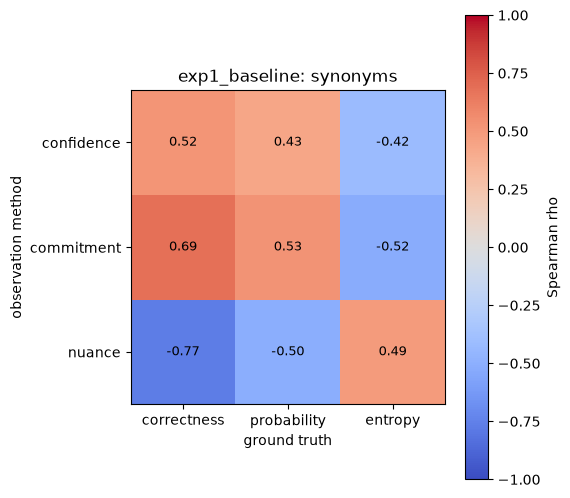


=== exp1_baseline / triviaqa (TriviaQA_limit200) ===


TriviaQA_limit200: observation methods:   0%|          | 0/3 [00:00<?, ?it/s]

TriviaQA_limit200: ground truths:   0%|          | 0/3 [00:00<?, ?it/s]

[[ 0.26166847  0.21632194 -0.232506  ]
 [ 0.30603418  0.40454739 -0.41162086]
 [-0.07707551 -0.60935896  0.62687028]]


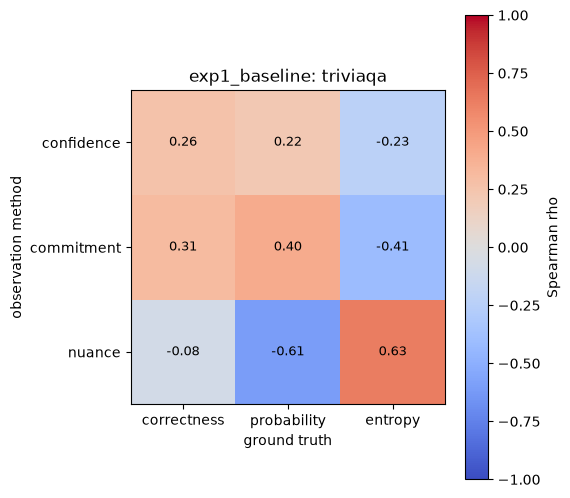

In [13]:
BASELINE_OMS = [ConfidenceOM(), CommitmentOM(), NuanceOM()]
BASELINE_GTS = [CorrectnessGT(), ProbabilityGT(), EntropyGT()]

exp1_results = run_and_plot(GENERAL_DATASETS, BASELINE_OMS, BASELINE_GTS, "exp1_baseline")


## Experiment 2: Full calibration

Inserts `ChallengeOM`/`ChallengeGT` as the third row/column
(`confidence, commitment, challenge, nuance` × `correctness, probability,
challenge, entropy`), over the same two datasets and the same `CACHE_DIR`:
the `confidence`/`commitment`/`nuance` × `correctness`/`probability`/
`entropy` block is a cache hit from experiment 1 (see the "loaded ... from
cache" prints below vs. experiment 1's own generation prints above); only
`challenge`'s row/column actually runs a fresh (and considerably more
expensive — two extra generation passes per trial) computation. `ChallengeGT`
needs the loaded model bound at construction, unlike every other ground
truth here.

exp2_full: datasets:   0%|          | 0/2 [00:00<?, ?it/s]


=== exp2_full / synonyms (Synonyms_n67) ===


Synonyms_n67: observation methods:   0%|          | 0/4 [00:00<?, ?it/s]

Synonyms_n67: challenge observations:   0%|          | 0/200 [00:00<?, ?it/s]

Synonyms_n67: ground truths:   0%|          | 0/4 [00:00<?, ?it/s]

challenge: baseline vs. challenged margins:   0%|          | 0/200 [00:00<?, ?it/s]

[[ 0.51647206  0.43266001  0.51206195 -0.42009943]
 [ 0.68716055  0.53027779  0.59616745 -0.52184579]
 [ 0.45032942  0.36029407  0.36029469 -0.35390585]
 [-0.76869472 -0.50011289 -0.61497238  0.48928358]]


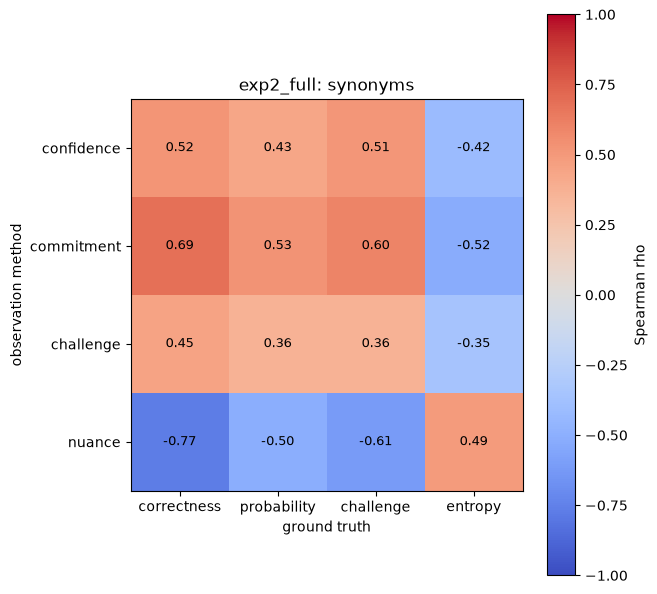


=== exp2_full / triviaqa (TriviaQA_limit200) ===


TriviaQA_limit200: observation methods:   0%|          | 0/4 [00:00<?, ?it/s]

TriviaQA_limit200: ground truths:   0%|          | 0/4 [00:00<?, ?it/s]

[[ 0.26166847  0.21632194  0.03378378 -0.232506  ]
 [ 0.30603418  0.40454739  0.06891153 -0.41162086]
 [-0.150568    0.08454111 -0.16243037 -0.06795412]
 [-0.07707551 -0.60935896  0.06590439  0.62687028]]


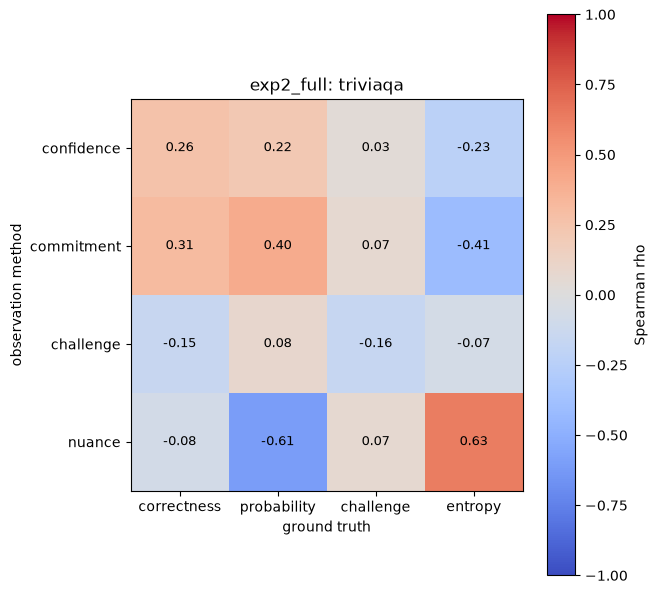

In [14]:
FULL_OMS = [ConfidenceOM(), CommitmentOM(), ChallengeOM(), NuanceOM()]
FULL_GTS = [CorrectnessGT(), ProbabilityGT(), ChallengeGT(loaded), EntropyGT()]

exp2_results = run_and_plot(GENERAL_DATASETS, FULL_OMS, FULL_GTS, "exp2_full")


## Experiment 3: List elicitation

`VarietyOM` × `{ListVarianceGT, TemperatureGT}` — `variety` is exclusive to
`ListElicitationDataset` (`impurity` moved to experiment 4 below, exclusive
to `TwentyQuestionsDataset` instead; the two no longer share a dataset).
`TemperatureGT` is a control column, not a real ground truth: it just reads
back `trial.seed.temperature`, the sampling temperature drawn *before*
generation ever happens — the model never sees this value, so `variety`
correlating against it should read approximately zero; a nonzero reading
would flag a leak, not a genuine calibration signal.

exp3_list: datasets:   0%|          | 0/1 [00:00<?, ?it/s]


=== exp3_list / list_elicitation (ListElicitation_n1k20T20) ===


ListElicitation_n1k20T20: generating trials:   0%|          | 0/200 [00:00<?, ?it/s]

ListElicitation_n1k20T20: observation methods:   0%|          | 0/1 [00:00<?, ?it/s]

ListElicitation_n1k20T20: variety observations:   0%|          | 0/200 [00:00<?, ?it/s]

ListElicitation_n1k20T20: ground truths:   0%|          | 0/2 [00:00<?, ?it/s]

[[0.22385087 0.24369218]]


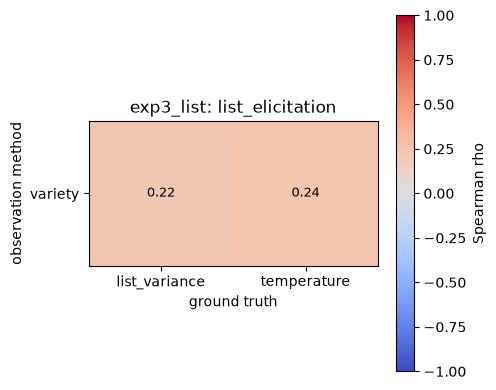

ListElicitation_n1k20T20: observation methods:   0%|          | 0/1 [00:00<?, ?it/s]

ListElicitation_n1k20T20: ground truths:   0%|          | 0/2 [00:00<?, ?it/s]

[[0.22385087 0.24369218]
 [0.1829653  1.        ]]


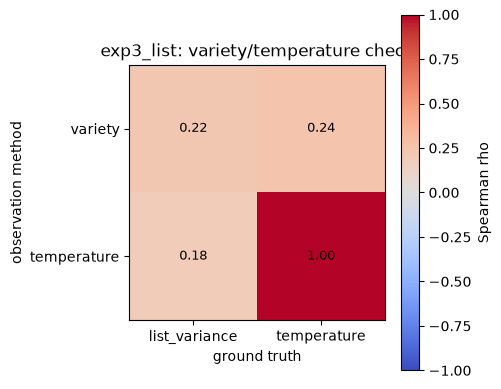

In [15]:
LIST_OMS = [VarietyOM()]
LIST_GTS = [ListVarianceGT(), TemperatureGT()]

exp3_results = run_and_plot({"list_elicitation": list_elicitation}, LIST_OMS, LIST_GTS, "exp3_list")

# -- temperature as its own row too, not just a column ----------------------
# TemperatureGT's own values work just as well as "row" values as they do as
# "column" values -- there's no model self-report to elicit for it either
# way, it's a bare seed field read back verbatim regardless of which axis it
# sits on. Reuses calib.correlation_matrix directly (rather than
# reimplementing spearmanr by hand) via a synthetic "temperature" entry
# spliced into the observations dict, using SimpleNamespace stand-ins for the
# row/col "methods" since correlation_matrix only ever reads their `.name`.
#
# This gives a 2x2 of {variety, temperature} x {list_variance, temperature}:
# (temperature, temperature) is a trivial identity check (rho should read
# exactly 1.0 -- if it doesn't, something is wrong with this cell, not with
# vonto); (temperature, list_variance) is the real addition -- does the
# (currently-unused-by-generation) seed temperature correlate with the
# ACTUAL computed variance, as opposed to only with the model's own
# self-reported variety (the exp3_results run above already covers
# (variety, temperature) and (variety, list_variance)).
list_trials = calib.generate_trials(loaded, list_elicitation, N_TRIALS, CACHE_DIR, rng_seed=0)
variety_obs = calib.observe_all(loaded, list_trials, [VarietyOM()], CACHE_DIR, list_elicitation.shape_tag())
list_grades = calib.grade_all(list_trials, [ListVarianceGT(), TemperatureGT()], CACHE_DIR, list_elicitation.shape_tag())
variety_obs["temperature"] = [(str(v), v) for v in list_grades["temperature"]]

ROW_SPECS = [SimpleNamespace(name="variety"), SimpleNamespace(name="temperature")]
COL_SPECS = [SimpleNamespace(name="list_variance"), SimpleNamespace(name="temperature")]
temperature_check_matrix = calib.correlation_matrix(variety_obs, list_grades, ROW_SPECS, COL_SPECS)
print(temperature_check_matrix)
plot_heatmap(
    temperature_check_matrix, ["variety", "temperature"], ["list_variance", "temperature"],
    title="exp3_list: variety/temperature check",
    save_path=FIG_DIR / "exp3_list_temperature_check_heatmap.png",
)


### Per-keyword temperature vs. list-variance

The pooled correlation above mixes 10 different keywords, each with its own
baseline diversity (some keywords' completions cluster tightly regardless of
temperature, others range widely even at low temperature) -- that between-keyword
spread can swamp a real within-keyword temperature effect in a single pooled
Spearman rho. Breaking it down by keyword (`T` temperatures each, from
`list_elicitation`'s own per-keyword draws) checks whether a real effect is hiding
inside the null pooled number, and whether it's at least consistent in sign across
keywords.

In [16]:
from collections import defaultdict

by_keyword = defaultdict(lambda: ([], []))
for trial, temp, variance in zip(list_trials, list_grades["temperature"], list_grades["list_variance"]):
    temps, variances = by_keyword[trial.seed.keyword]
    temps.append(temp)
    variances.append(variance)

print(f"{'keyword':12s} {'n':>3s}  {'mean_variance':>13s}  {'rho':>7s}  {'p':>6s}")
per_keyword_rho = {}
for keyword, (temps, variances) in by_keyword.items():
    rho, p = spearmanr(temps, variances)
    per_keyword_rho[keyword] = rho
    print(f"{keyword:12s} {len(temps):3d}  {sum(variances) / len(variances):13.3f}  {rho:+.3f}  {p:.3f}")

n_positive = sum(1 for rho in per_keyword_rho.values() if rho > 0)
print(f"\n{n_positive}/{len(per_keyword_rho)} keywords positive; "
      f"mean per-keyword rho = {sum(per_keyword_rho.values()) / len(per_keyword_rho):+.3f}")


keyword        n  mean_variance      rho       p
killer        20          0.350  -0.263  0.262
tobacco       20          0.360  +0.385  0.094
juice         20          0.343  -0.488  0.029
hemisphere    20          0.180  +0.629  0.003
buses         20          0.212  +0.327  0.159
motel         20          0.258  +0.317  0.174
locker        20          0.229  +0.320  0.169
fear          20          0.287  +0.100  0.675
camp          20          0.323  +0.756  0.000
beauty        20          0.325  -0.167  0.482

7/10 keywords positive; mean per-keyword rho = +0.192


## Experiment 4: Twenty questions

`ImpurityOM` × `ImpurityGT` only — `impurity` is exclusive to
`TwentyQuestionsDataset` (see the class docstrings): the self-report asks
the model how evenly it thinks the question it just proposed splits the
remaining candidates (reminded, in the same prompt, that the most efficient
20-Questions play always tries to split them as evenly as possible); the
ground truth actually classifies each candidate under the model's own
proposed question (`vonto.twenty_questions.parse_partition`) and computes
the real Gini impurity of that split. `ImpurityGT` needs the loaded model
bound at construction — classifying candidates is itself a model call, not a
deterministic computation.

exp4_twentyq: datasets:   0%|          | 0/1 [00:00<?, ?it/s]


=== exp4_twentyq / twenty_questions (TwentyQuestions_n_games20k128T2) ===


TwentyQuestions_n_games20k128T2: observation methods:   0%|          | 0/1 [00:00<?, ?it/s]

TwentyQuestions_n_games20k128T2: ground truths:   0%|          | 0/1 [00:00<?, ?it/s]

[[0.30598545]]


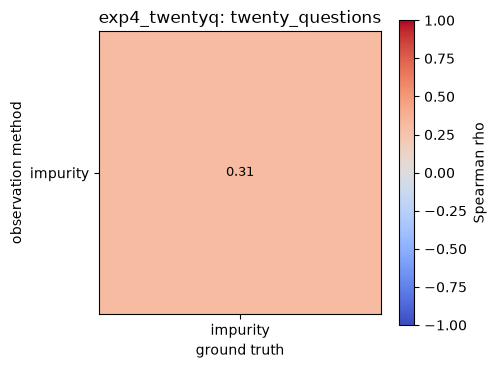

In [17]:
TWENTYQ_OMS = [ImpurityOM()]
TWENTYQ_GTS = [ImpurityGT(loaded)]

exp4_results = run_and_plot(
    {"twenty_questions": twenty_questions}, TWENTYQ_OMS, TWENTYQ_GTS, "exp4_twentyq",
)
